# Exploratory Data Analysis (EDA) - Telco Customer Churn

## Objective
The goal of this notebook is to understand the dataset's characteristics, identify data quality issues, explore feature distributions, and determine the necessary preprocessing steps (Data Readiness) before training our neural network.

**Key Requirements Checked:**
- Data Volume
- Data Quality (Missing values, types)
- Distributions (Target and Features)
- Data Readiness

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

In [17]:
data_path = "../data/raw/telco_churn.csv"

try:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully!")
    print(f"Data Volume: {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: Dataset not found. Please ensure 'telco_churn.csv' is in the data/raw/ directory.")

df.head()

Dataset loaded successfully!
Data Volume: 7043 rows and 33 columns.


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [18]:
# 2. Data Quality & Types
print("Data Types and Missing Values")
df.info()

print("\nExplicit Missing Values")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print("\n--- Missing Values after TotalCharges conversion ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

df.dropna(inplace=True)
print(f"\nFinal Volume after dropping NaNs: {df.shape[0]} rows.")

Data Types and Missing Values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 

--- Target Variable Distribution ---
Churn Label
Yes    100.0
Name: proportion, dtype: float64


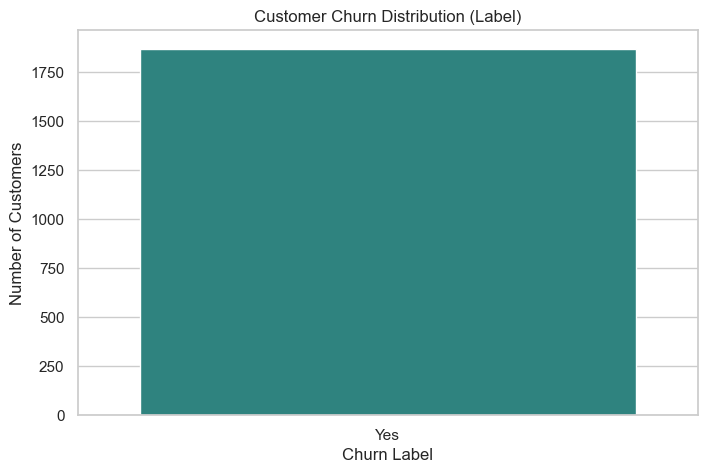

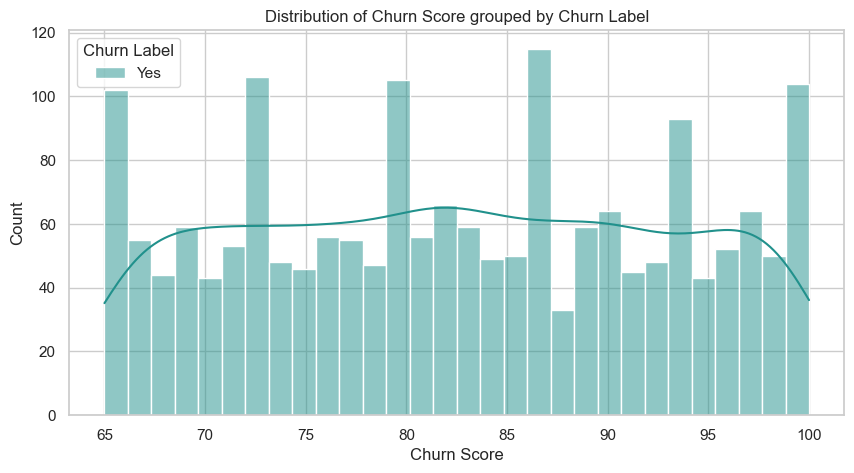

In [19]:
target_col = 'Churn Label'

if target_col in df.columns:
    print("--- Target Variable Distribution ---")
    churn_ratio = df[target_col].value_counts(normalize=True) * 100
    print(churn_ratio)

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=target_col, palette='viridis')
    plt.title("Customer Churn Distribution (Label)")
    plt.ylabel("Number of Customers")
    plt.show()
else:
    print(f"Error: '{target_col}' not found.")

if 'Churn Score' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='Churn Score', hue='Churn Label', kde=True, palette='viridis', bins=30)
    plt.title("Distribution of Churn Score grouped by Churn Label")
    plt.show()


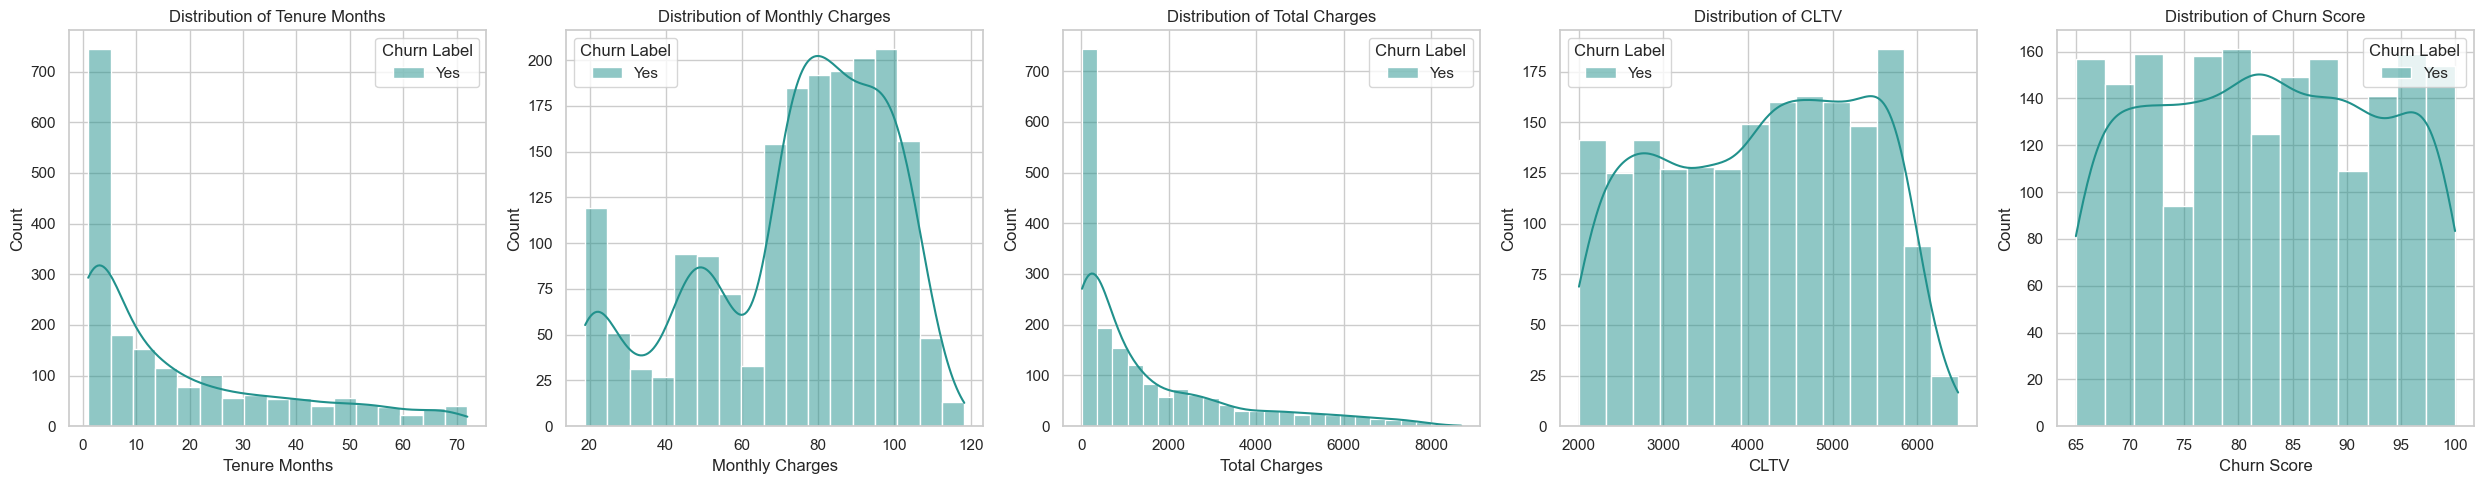

In [20]:
expected_numerical = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']

existing_num_features = [col for col in expected_numerical if col in df.columns]

if existing_num_features:

    fig, axes = plt.subplots(1, len(existing_num_features), figsize=(5 * len(existing_num_features), 5))

    if len(existing_num_features) == 1:
        axes = [axes]
        
    for i, col in enumerate(existing_num_features):
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {col}')

    plt.tight_layout()
    plt.show()
else:
    print("Error: None of the specified numerical features were found in the dataset. Please verify column names using df.columns.")

## Data Readiness & Next Steps

Based on our Exploratory Data Analysis, i have a comprehensive understanding of the dataset's structure and the required preprocessing steps to achieve Data Readiness for our Neural Network and Baseline models.

### Key Insights from EDA:
1. **Target Variable Configuration:** The dataset provides `Churn Label` (text) and `Churn Value` (numeric 1/0). The numeric target is already encoded, simplifying our pipeline. I must drop `Churn Label` before modeling.
2. **Behavioral Patterns:** - Customers with lower `Tenure Months` (newer customers) have a significantly higher concentration of churn.
   - Higher `Monthly Charges` (especially between 70 and 110) strongly correlate with churn.
   - The `Churn Score` distribution for churned customers shows a high density above 80, confirming its predictive power, though we must decide if it's fair to use it as a feature or if it constitutes data leakage (depending on how it was originally calculated).
3. **Data Quality Flags:** The `Churn Reason` column has 5174 missing values (likely because non-churned customers don't have a reason). I will drop this column entirely, as it is only known *after* the churn event occurs (Data Leakage).

### Required Preprocessing Pipeline (Action Plan):
1. **Feature Selection (Drop List):** Remove non-predictive identifiers (`CustomerID`, `Count`, `Lat Long`) and columns that cause data leakage (`Churn Label`, `Churn Reason`). I will also drop geo-data like `Latitude`, `Longitude`, `Country`, `State`, `City`, and `Zip Code` for the baseline iteration to simplify the model.
2. **Handling Missing Values:** Implicit nulls in `Total Charges` have been identified and handled.
3. **Categorical Encoding:** Features like `Gender`, `Senior Citizen`, `Partner`, `Internet Service`, etc., require One-Hot Encoding or Ordinal Encoding depending on cardinality.
4. **Numerical Scaling:** Numerical columns (`Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`, `Churn Score`) must be scaled (e.g., using `StandardScaler`). Neural Networks are highly sensitive to unscaled inputs, which can slow convergence or cause exploding gradients.
5. **Class Imbalance Strategy:** Since churn is typically an imbalanced event, we will configure our MLflow tracking to evaluate models based on `AUC-ROC`, `PR-AUC`, and `F1-Score`, rather than relying on accuracy.